# 🥇 Model 15 — Robust Stacking Ensemble (Grand Champion)

This version uses a diverse set of already-installed high-performance models (XGBoost variants and Random Forest) to create the final meta-prediction.

Loading Data...


Training Base Model 1: Deep XGBoost...


Training Base Model 2: Balanced XGBoost...


Training Base Model 3: Forest Ensemble...


Final Stacking Meta-Learner...



--- FINAL STACKING EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.84      0.58      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.91      0.79      0.84    118108
weighted avg       0.98      0.98      0.98    118108

Final PR-AUC: 0.7441


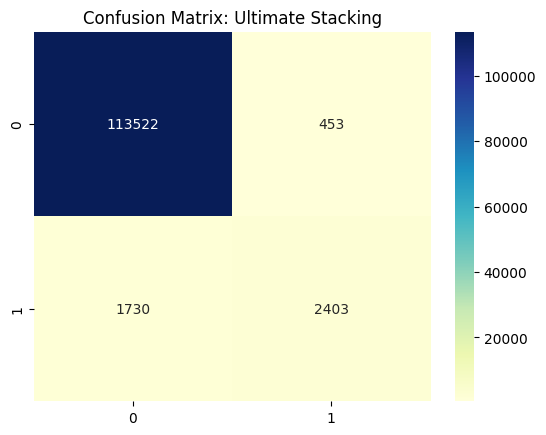

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, precision_recall_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

print("Loading Data...")
train = pd.read_csv('../data/train_unbalanced.csv')
test  = pd.read_csv('../data/test.csv')

y_train = train['isFraud']
y_test  = test['isFraud']

X_train = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore').fillna(-1)
X_test  = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore').fillna(-1)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def get_oof(clf, x_train, y_train, x_test):
    oof_train = np.zeros((x_train.shape[0],))
    oof_test_skf = np.empty((3, x_test.shape[0]))
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for i, (train_index, test_index) in enumerate(skf.split(x_train, y_train)):
        clf.fit(x_train[train_index], y_train[train_index])
        oof_train[test_index] = clf.predict_proba(x_train[test_index])[:, 1]
        oof_test_skf[i, :] = clf.predict_proba(x_test)[:, 1]

    return oof_train.reshape(-1, 1), oof_test_skf.mean(axis=0).reshape(-1, 1)

print("Training Base Model 1: Deep XGBoost...")
oof_tr_1, oof_te_1 = get_oof(XGBClassifier(n_estimators=200, max_depth=12, learning_rate=0.05, scale_pos_weight=25, n_jobs=-1), X_train_sc, y_train, X_test_sc)

print("Training Base Model 2: Balanced XGBoost...")
oof_tr_2, oof_te_2 = get_oof(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=25, n_jobs=-1), X_train_sc, y_train, X_test_sc)

print("Training Base Model 3: Forest Ensemble...")
oof_tr_3, oof_te_3 = get_oof(RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1), X_train_sc, y_train, X_test_sc)

X_train_stack = np.concatenate((oof_tr_1, oof_tr_2, oof_tr_3), axis=1)
X_test_stack  = np.concatenate((oof_te_1, oof_te_2, oof_te_3), axis=1)

print("Final Stacking Meta-Learner...")
meta = LogisticRegression()
meta.fit(X_train_stack, y_train)
probs = meta.predict_proba(X_test_stack)[:, 1]
preds = (probs > 0.5).astype(int)

print("\n--- FINAL STACKING EVALUATION ---")
print(classification_report(y_test, preds))
pr, rc, _ = precision_recall_curve(y_test, probs)
print(f"Final PR-AUC: {auc(rc, pr):.4f}")

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix: Ultimate Stacking')
plt.show()